# [LAB-07] 8-2. 이원분산분석의 사후검정 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import melt

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 📚 신입교사의 교육방법 채택 고민 — 국어는 다르지 않나요?

### 당신은 한울고등학교의 연구교사입니다.

지난 시간 이원분산분석으로 확인한 결과, 교육방법도 과목도 그 맞물림도 유의수준 5%에서는 유의하지 않았습니다. 당신은 "표본을 늘려 다시 검정해 보자"고 보고했습니다.

그러자 교장 선생님이 조합별 평균표를 짚으며 되묻습니다. "평균만 보면 2번 방법으로 배운 국어(81.4점)가 1번 방법으로 배운 국어(74.5점)보다 7점 가까이 높잖아요. 전체를 뭉뚱그리지 말고, 네 조합을 짝지어 하나씩 비교하면 다른 결론이 나오지 않겠습니까?"

네 개의 조합(교육방법 × 과목)을 서로 짝지어 비교하는 사후검정으로 교장 선생님의 반문에 답하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
df1 = load_data('edu')
df1.head()

📚 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65


#### 데이터 재배치

In [3]:
df1_long = melt(df1, id_vars='교육방법',
                value_vars=['국어', '영어'],
                var_name='과목', value_name='점수')

print(f"관측치 개수: {len(df1_long)}")

df1_long.head()

관측치 개수: 44


,교육방법,과목,점수
0,1,국어,65
1,1,국어,87
2,1,국어,73
3,1,국어,79
4,1,국어,81


#### 사후분석

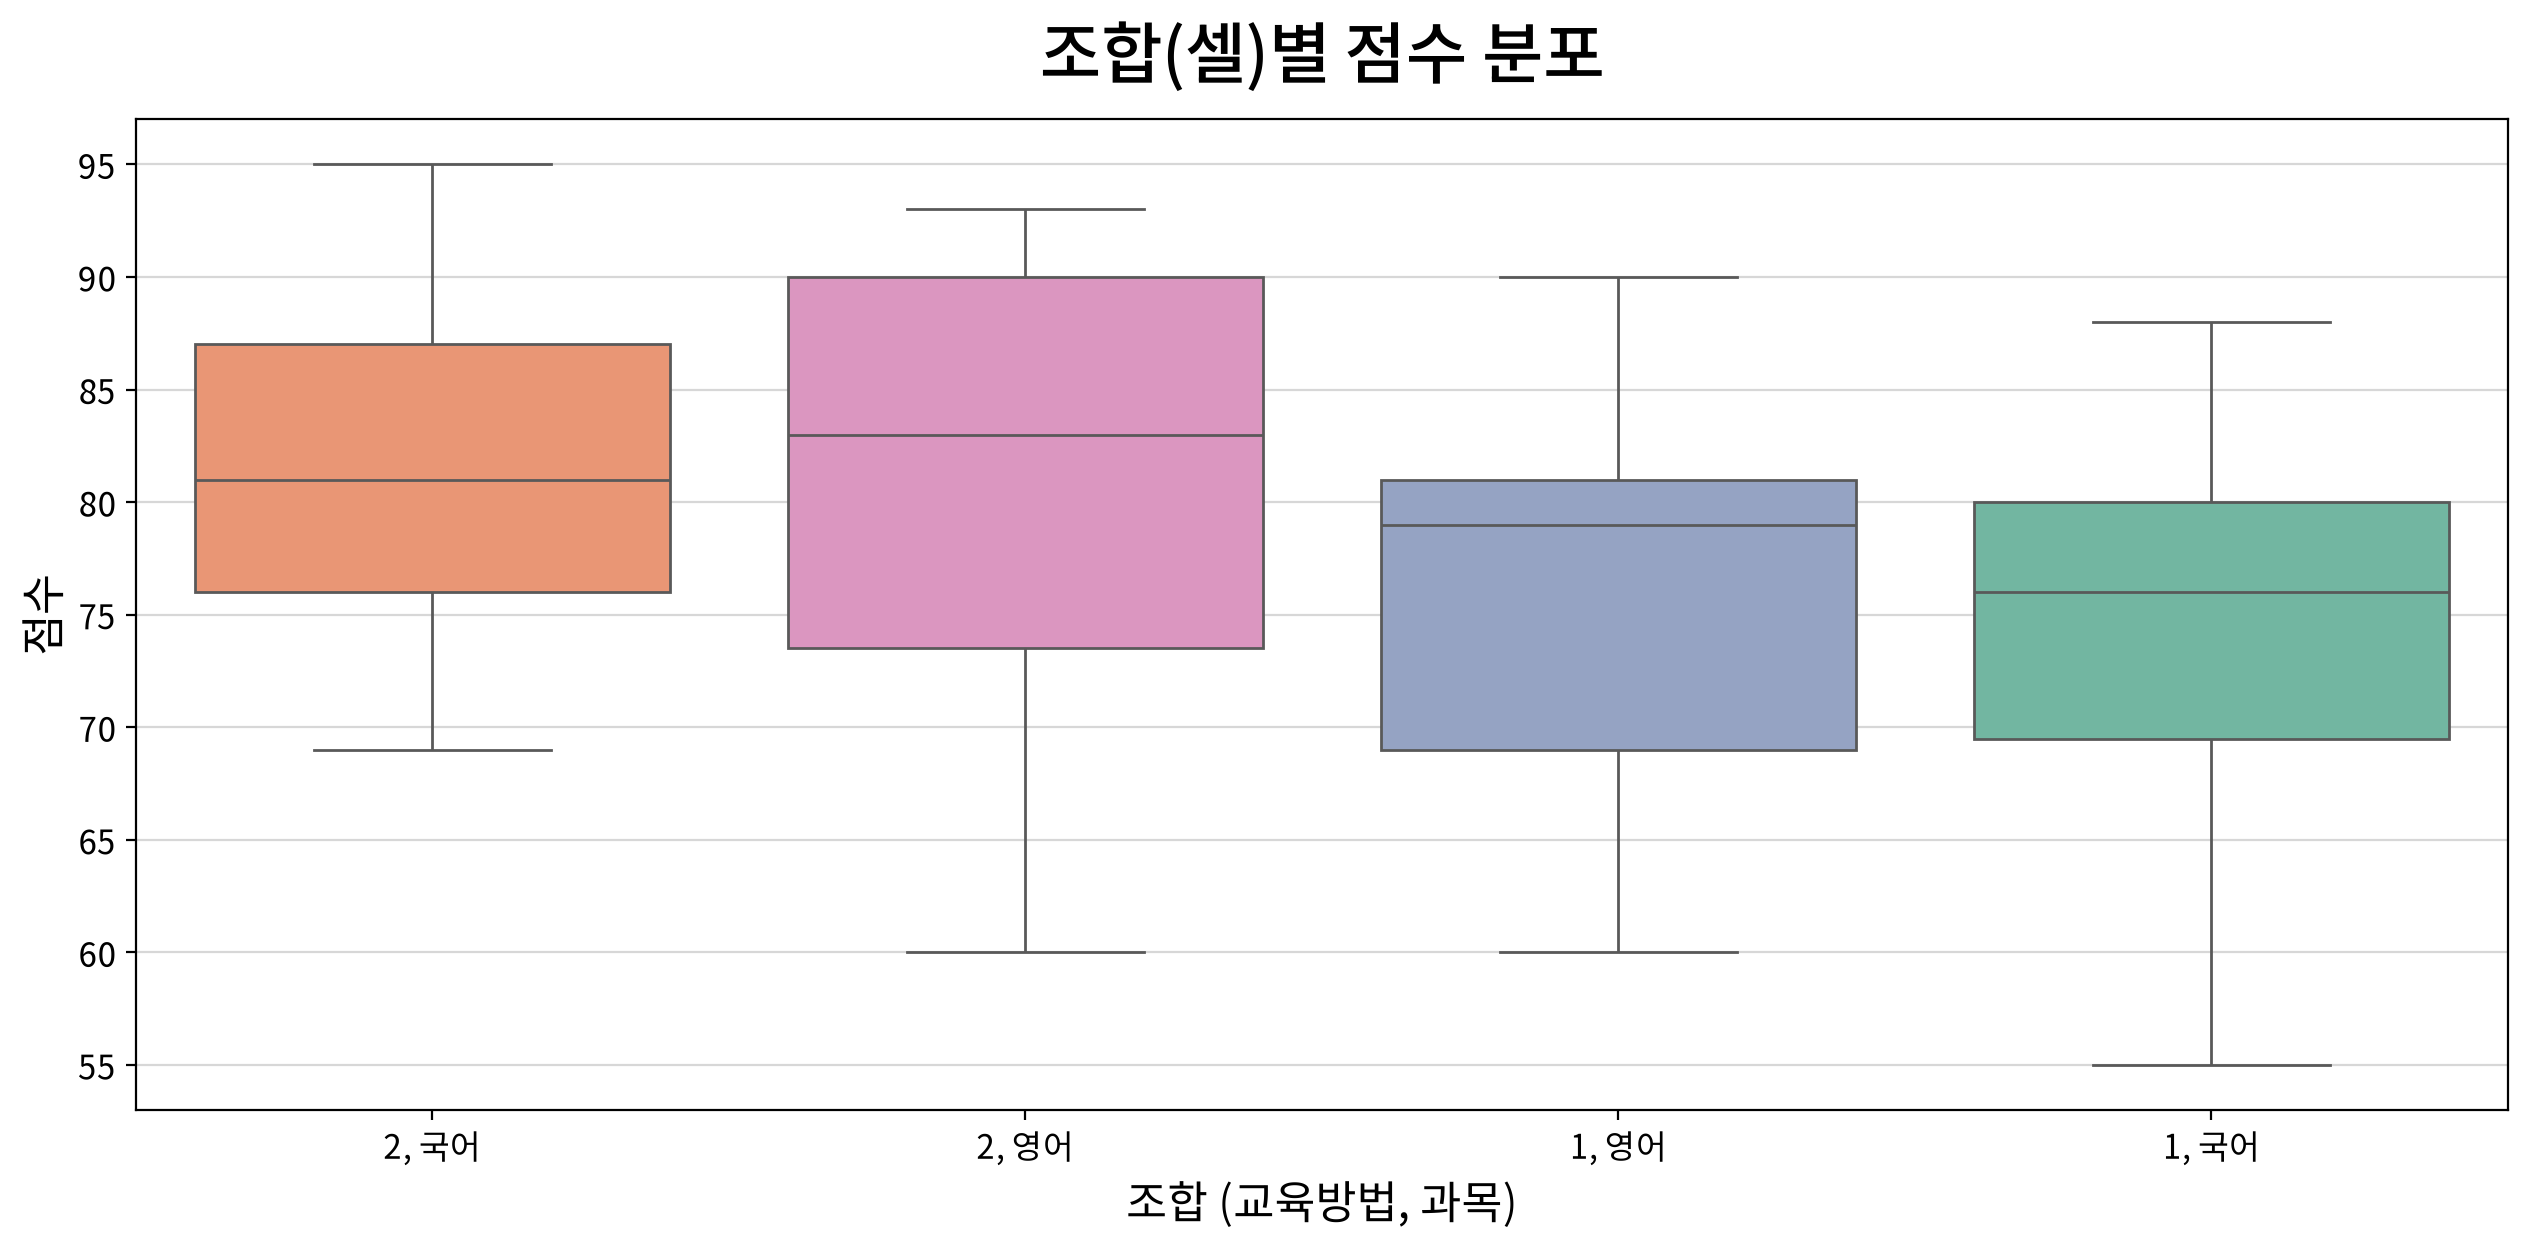

비교한 조합 쌍: 6개
유의한 쌍: 0개
평균 차이가 가장 큰 쌍: (1, 국어) vs (2, 국어) → 차이 6.818, 효과크기 Medium, p-value 0.356
평균 차이가 가장 작은 쌍: (2, 국어) vs (2, 영어) → 차이 1.000, 효과크기 Negligible, p-value 0.995

[1] 1쌍 중 유의한 쌍: 0개
(유의한 쌍 없음)

[2] 1쌍 중 유의한 쌍: 0개
(유의한 쌍 없음)


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"1, 국어","1, 영어",74.545,75.818,-1.273,4.097,-0.311,0.989,-0.131,False,Negligible
1,Tukey HSD,"1, 국어","2, 국어",74.545,81.364,-6.818,4.097,-1.664,0.356,-0.740,False,Medium
2,Tukey HSD,"1, 국어","2, 영어",74.545,80.364,-5.818,4.097,-1.420,0.495,-0.530,False,Medium
3,Tukey HSD,"1, 영어","2, 국어",75.818,81.364,-5.545,4.097,-1.353,0.535,-0.624,False,Medium
4,Tukey HSD,"1, 영어","2, 영어",75.818,80.364,-4.545,4.097,-1.109,0.686,-0.425,False,Small
5,Tukey HSD,"2, 국어","2, 영어",81.364,80.364,1.000,4.097,0.244,0.995,0.098,False,Negligible


In [4]:
post1 = my_stats.posthoc_twoway(df1_long, y='점수', between=['교육방법', '과목'], palette='Set2')
post1

### 문제 풀이

#### 1. 교장 선생님의 요구대로 네 개의 조합을 서로 짝지어 비교했습니다. 사후검정이 비교한 조합 쌍은 모두 몇 개 인가요?

- **정답**: `6`
- **복습 개념**: 사후검정(post-hoc test)의 다중비교 구조입니다. 분산분석은 "어딘가에 차이가 있다"까지만 말해 주므로, 어느 조합끼리 다른지는 조합을 둘씩 짝지어 다시 비교해야 알 수 있습니다.
- **풀이 접근**: 교육방법 2수준 × 과목 2수준 = 4개 조합이 만들어집니다. 이 4개에서 둘씩 고르는 경우의 수를 세거나, 사후검정 결과표의 행 수를 확인합니다.
- **근거(계산 결과)**: 4개 조합에서 두 개를 고르는 조합의 수는 4×3÷2 = **6쌍**입니다. 결과표도 (1,국어)-(1,영어)부터 (2,국어)-(2,영어)까지 6행으로 나옵니다.
- **헷갈리기 쉬운 점**: 비교 쌍이 늘어날수록 우연히 유의해지는 쌍이 생기기 쉽습니다. Tukey HSD 같은 사후검정은 이 다중비교 문제를 보정해 주기 때문에, 쌍마다 t검정을 따로 돌리는 것보다 보수적인 결과를 냅니다.

#### 2. 교장 선생님이 지목한 것처럼, 평균 점수 차이가 가장 큰 쌍은 1번-국어와 2번-국어의 비교였습니다. 이 두 조합의 평균 차이는 몇 점 인가요? (소수 셋째 자리, 부호 없이)

- **정답**: `6.818`
- **복습 개념**: 사후검정 결과표의 `mean_A`·`mean_B`·`diff` 열 읽기입니다. 각 쌍의 평균 차이가 실제로 몇 점인지 확인합니다.
- **풀이 접근**: 결과표에서 `diff` 열의 절댓값이 가장 큰 행을 찾습니다. 조합별 평균표에서 직접 빼서 확인해도 같습니다.
- **근거(계산 결과)**: (1, 국어) 74.545점과 (2, 국어) 81.364점의 차이는 **6.818점**입니다. 6쌍 중 가장 큰 차이이고, 교장 선생님이 "7점 가까이 높다"고 말한 바로 그 숫자입니다.

#### 3. 그렇다면 이 6개의 쌍 중에서 유의수준 5%에서 통계적으로 유의한 차이를 보인 쌍은 몇 개 인가요?

- **정답**: `0`
- **복습 개념**: 사후검정에서의 유의성 판정입니다. 평균 차이가 눈에 띄게 커 보여도, 그 차이가 표본의 우연으로 설명될 수 있으면 유의하지 않다고 판정합니다.
- **풀이 접근**: 결과표의 `pval` 열을 0.05와 비교하거나 `significant` 열이 True인 행을 셉니다.
- **근거(계산 결과)**: 6쌍의 pval은 0.356 / 0.495 / 0.535 / 0.686 / 0.989 / 0.995로 전부 0.05를 크게 웃돕니다 → 유의한 쌍은 **0개**입니다. 지난 시간 이원분산분석에서 유의한 효과가 0개였던 것과 일치하는 결과입니다.

#### 4. 유의한 쌍은 없었지만 효과크기까지 무시할 수준은 아니었습니다. 6개의 쌍 중 효과크기가 Medium으로 판정된 쌍은 몇 개 인가요?

- **정답**: `3`
- **복습 개념**: 사후검정 결과표의 효과크기(hedges' g) 판정입니다. 유의성(pval)과 효과크기는 서로 다른 질문에 답하므로, 유의하지 않은 쌍도 효과크기는 중간일 수 있습니다.
- **풀이 접근**: 결과표의 `effect_size` 열에서 Medium인 행을 셉니다.
- **근거(계산 결과)**: Medium **3쌍**(1,국어–2,국어 / 1,국어–2,영어 / 1,영어–2,국어), Small 1쌍, Negligible 2쌍입니다. Medium인 세 쌍은 모두 **교육방법이 서로 다른** 비교이고, 같은 교육방법 안에서 과목만 다른 두 쌍은 Negligible입니다.
- **함께 생각해 볼 점**: "차이가 없다"가 아니라 "차이를 확인할 만큼의 증거가 없다"입니다. 교육방법이 다른 쌍에서만 효과크기가 중간으로 나온다는 것은, 점수를 가르는 것이 과목이 아니라 교육방법 쪽이라는 신호이기도 합니다.

#### 5. 교장 선생님이 콕 집어 물은 1번-국어 대 2번-국어 쌍은, 6쌍 중 평균 차이가 가장 크고 유의확률도 가장 작았습니다. 그 유의확률은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.356`
- **복습 개념**: 다중비교 보정 후의 유의확률 해석입니다. 6쌍 중 '가장 그럴듯한' 쌍조차 기준선에 얼마나 못 미치는지 확인하는 것이 사후검정의 마무리입니다.
- **풀이 접근**: 결과표에서 A가 (1, 국어), B가 (2, 국어)인 행의 `pval`을 읽습니다. `pval` 열의 최솟값을 찾아도 같은 행이 나옵니다.
- **근거(계산 결과)**: p = **0.356** 입니다. 0.05는 물론 0.1과 비교해도 한참 큰 값입니다. 평균 차이 6.818점은 이 표본에서 우연히 생길 수 있는 정도라는 뜻입니다.
- **결론**: 당신이 교장 선생님께 드릴 답은 이렇습니다. "조합을 하나씩 짝지어 봐도 결론은 같습니다. 가장 유망해 보이던 국어 비교조차 p=0.356으로, 7점 차이를 우연이 아니라고 말할 근거가 없습니다. 집단당 11명이라는 표본이 너무 작습니다." 사후검정은 분산분석의 결론을 뒤집는 도구가 아니라, **어느 조합에서 차이가 났는지 짚어 주는 도구**입니다.

## 📚 응급의료센터의 표준 해독제 선정 — 통계적으로 확실한가요?

### 당신은 독성학연구소의 신입 연구원입니다.

지난 시간 이원분산분석에서 독극물·해독제·둘의 상호작용이 모두 유의하게 나왔고, 조합별 평균을 근거로 당신은 "단일 표준 해독제 대신 독극물별 맞춤 프로토콜(P1은 T2, P2·P3는 T4)"을 제안했습니다.

응급의료센터가 다시 묻습니다. "평균이 조금 높다고 해독제를 바꾸려면 현장 교육을 다시 해야 합니다. 그 차이가 **통계적으로 확실한** 조합만 골라 주세요. P1에서 T2가 T1보다 정말 낫다고 말할 수 있습니까?"

12개 조합(독극물 × 해독제)을 서로 짝지어 비교하는 사후검정으로, 어느 조합 사이의 차이가 실제로 유의한지 확인하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [5]:
df2 = load_data('poisons')
df2.head()

📚 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)


,time,poison,treat
0,3.800,P1,T1
1,2.700,P1,T1
2,1.700,P1,T1
3,2.200,P1,T1
4,0.700,P1,T1


#### 사후분석

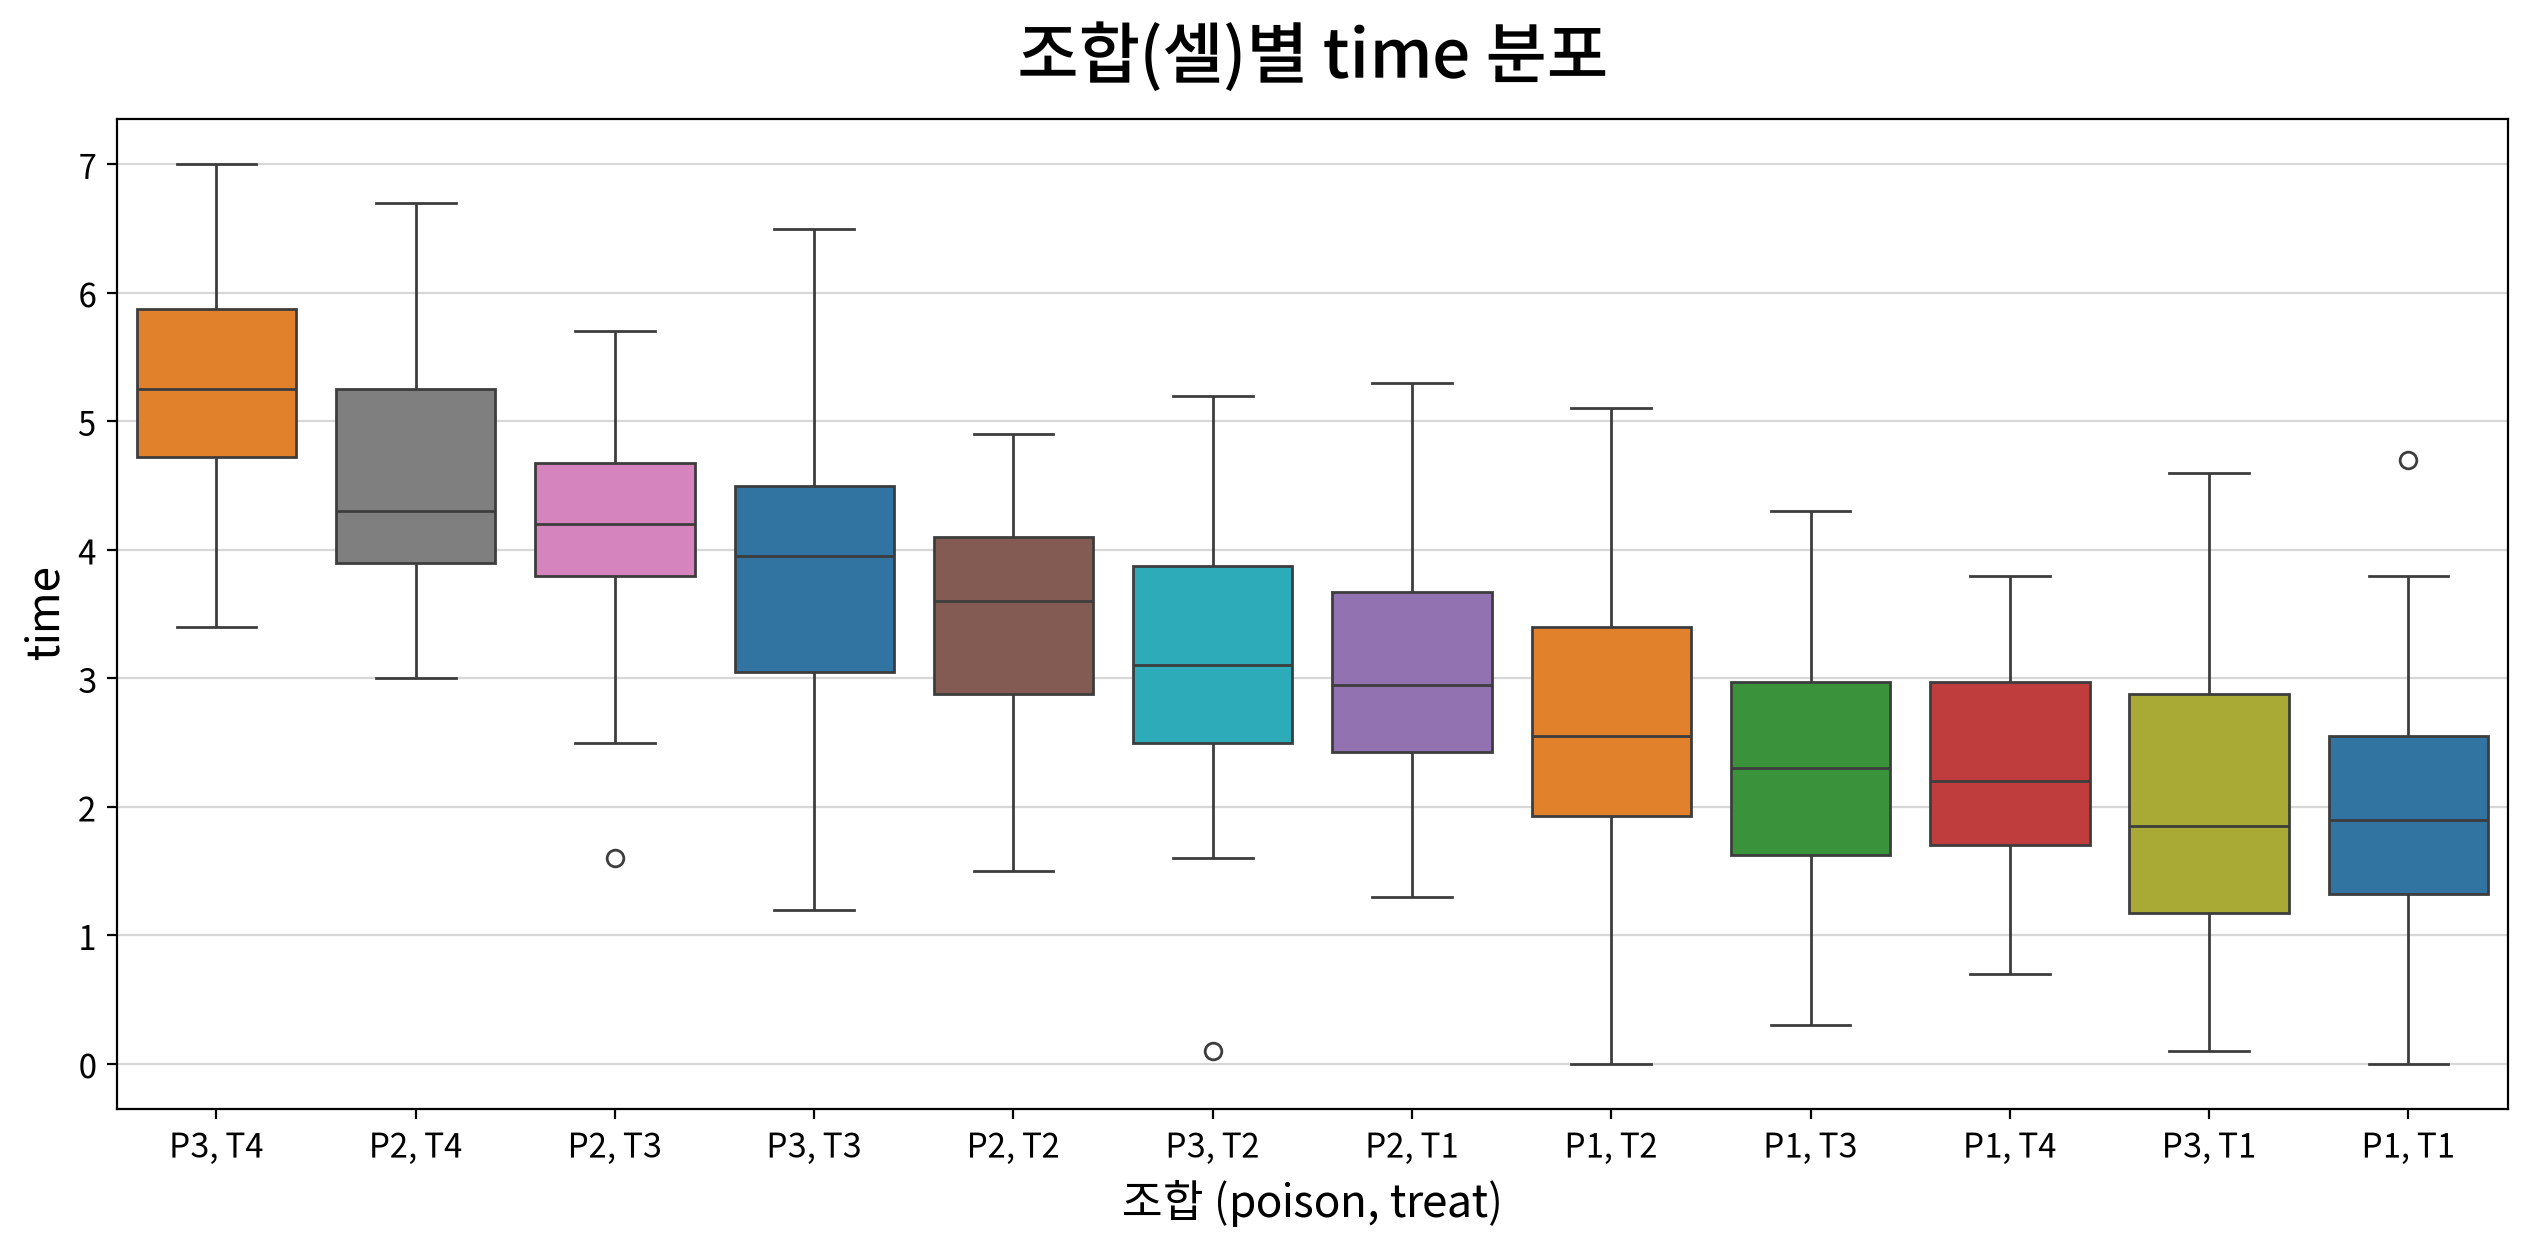

비교한 조합 쌍: 66개
유의한 쌍: 38개
평균 차이가 가장 큰 쌍: (P1, T1) vs (P3, T4) → 차이 3.307, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (P2, T1) vs (P3, T2) → 차이 0.053, 효과크기 Negligible, p-value 1.000

[P1] 6쌍 중 유의한 쌍: 0개
(유의한 쌍 없음)

[P2] 6쌍 중 유의한 쌍: 3개
     A      B   diff  pval  significant
P2, T1 P2, T3 -1.073 0.002         True
P2, T1 P2, T4 -1.467 0.000         True
P2, T2 P2, T4 -1.103 0.001         True

[P3] 6쌍 중 유의한 쌍: 5개
     A      B   diff  pval  significant
P3, T1 P3, T2 -1.083 0.002         True
P3, T1 P3, T3 -1.710 0.000         True
P3, T1 P3, T4 -3.247 0.000         True
P3, T2 P3, T4 -2.163 0.000         True
P3, T3 P3, T4 -1.537 0.000         True


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"P1, T1","P1, T2",1.980,2.670,-0.690,0.258,-2.677,0.243,-0.649,False,Medium
1,Tukey HSD,"P1, T1","P1, T3",1.980,2.370,-0.390,0.258,-1.513,0.936,-0.402,False,Small
2,Tukey HSD,"P1, T1","P1, T4",1.980,2.280,-0.300,0.258,-1.164,0.991,-0.328,False,Small
3,Tukey HSD,"P1, T1","P2, T1",1.980,3.070,-1.090,0.258,-4.228,0.002,-1.056,True,Large
4,Tukey HSD,"P1, T1","P2, T2",1.980,3.433,-1.453,0.258,-5.638,0.000,-1.480,True,Large
5,Tukey HSD,"P1, T1","P2, T3",1.980,4.143,-2.163,0.258,-8.392,0.000,-2.203,True,Large
6,Tukey HSD,"P1, T1","P2, T4",1.980,4.537,-2.557,0.258,-9.917,0.000,-2.569,True,Large
7,Tukey HSD,"P1, T1","P3, T1",1.980,2.040,-0.060,0.258,-0.233,1.000,-0.057,False,Negligible
8,Tukey HSD,"P1, T1","P3, T2",1.980,3.123,-1.143,0.258,-4.435,0.001,-1.110,True,Large
9,Tukey HSD,"P1, T1","P3, T3",1.980,3.750,-1.770,0.258,-6.866,0.000,-1.583,True,Large


In [6]:
post2 = my_stats.posthoc_twoway(df2, y='time', between=['poison', 'treat'], palette='tab10')
post2

### 문제 풀이

#### 1. 12개 조합을 서로 짝지어 비교했습니다. 사후검정이 비교한 조합 쌍은 모두 몇 개 인가요?

- **정답**: `66`
- **복습 개념**: 다중비교의 규모입니다. 조합이 늘어나면 비교해야 할 쌍은 훨씬 빠르게 늘어납니다.
- **풀이 접근**: 독극물 3종 × 해독제 4종 = 12개 조합에서 둘씩 고르는 경우의 수를 세거나, 사후검정 결과표의 행 수를 확인합니다.
- **근거(계산 결과)**: 12개에서 두 개를 고르는 조합의 수는 12×11÷2 = **66쌍**입니다.
- **헷갈리기 쉬운 점**: 조합이 4개였던 앞 문제에서는 6쌍이었는데, 12개가 되자 66쌍으로 11배가 됐습니다. 이렇게 비교가 많아지면 우연히 유의해지는 쌍이 생기기 마련이라, Tukey HSD처럼 다중비교를 보정하는 사후검정을 써야 합니다.

#### 2. 66개의 쌍 중에서 유의수준 5%에서 통계적으로 유의한 차이를 보인 쌍은 몇 개 인가요?

- **정답**: `38`
- **복습 개념**: 사후검정의 유의성 판정입니다. 이원분산분석이 "어딘가에 차이가 있다"고 알려 준 뒤, 그 차이가 정확히 어느 쌍에서 나는지를 짚어 줍니다.
- **풀이 접근**: 결과표에서 `significant` 열이 True인 행을 세거나, `pval`이 0.05보다 작은 행을 셉니다.
- **근거(계산 결과)**: 66쌍 중 **38쌍**이 유의합니다(나머지 28쌍은 유의하지 않습니다). 앞 문제의 edu 데이터에서는 6쌍 중 0쌍이었던 것과 대조적입니다. 조합당 30개체씩 총 360개체라는 넉넉한 표본이 차이를 또렷하게 드러낸 것입니다.

#### 3. 평균 생존시간의 차이가 가장 크게 벌어진 쌍은 (P1, T1)과 (P3, T4)의 비교였습니다. 이 두 조합의 평균 차이는 몇 시간 인가요? (소수 셋째 자리, 부호 없이)

- **정답**: `3.307`
- **복습 개념**: 사후검정 결과표의 `diff` 열 읽기입니다. 가장 나쁜 조합과 가장 좋은 조합의 간격이 곧 이 실험에서 해독제 선택이 만들어 낼 수 있는 최대 효과입니다.
- **풀이 접근**: 결과표에서 `diff` 열의 절댓값이 가장 큰 행을 찾습니다.
- **근거(계산 결과)**: (P1, T1)의 평균 1.980시간, (P3, T4)의 평균 5.287시간 → 차이는 **3.307시간**입니다. pval은 0.000이고 효과크기는 Large입니다.

#### 4. P1에 중독된 개체 안에서 해독제끼리 비교한 6개의 쌍 중, 유의한 차이를 보인 쌍은 몇 개 인가요?

- **정답**: `0`
- **복습 개념**: "평균이 가장 높다"와 "통계적으로 더 낫다"는 다르다는 것을 확인하는 문항입니다. 사후검정은 평균 순위가 아니라 차이의 신뢰성을 판정합니다.
- **풀이 접근**: 결과표에서 A와 B가 모두 P1로 시작하는 행만 골라(6쌍) `significant` 열을 셉니다.
- **근거(계산 결과)**: P1 내부 6쌍의 pval은 0.243 / 0.936 / 0.991 / 0.991 / 0.936 / 1.000으로 전부 0.05보다 큽니다 → 유의한 쌍은 **0개**입니다. 지난 시간 "P1에는 T2(2.670시간)가 최선"이라고 봤지만, T1(1.980시간)과의 차이 0.690시간은 통계적으로 우연과 구별되지 않습니다.
- **실무 포인트**: "P1에서 T2가 T1보다 정말 낫습니까?"라는 센터의 질문에 대한 답은 **"그렇다고 말할 수 없습니다"** 입니다. 평균 순위만 보고 프로토콜을 바꾸면, 현장 교육 비용을 치르고도 효과를 얻지 못할 수 있습니다.

#### 5. 반대로 P3에 중독된 개체 안에서 해독제끼리 비교한 6개의 쌍 중, 유의한 차이를 보인 쌍은 몇 개 인가요?

- **정답**: `5`
- **복습 개념**: 상호작용이 유의하다는 말의 실질적 의미입니다. 해독제 선택이 갖는 무게가 독극물에 따라 완전히 다릅니다.
- **풀이 접근**: 결과표에서 A와 B가 모두 P3로 시작하는 행만 골라(6쌍) `significant` 열을 셉니다. P1에 대해 했던 것과 같은 방법입니다.
- **근거(계산 결과)**: P3 내부 6쌍 중 **5쌍**이 유의합니다. 유일하게 유의하지 않은 쌍은 (P3,T2)–(P3,T3)(p=0.388)이며, T4는 T1·T2·T3 모두를 상대로 유의하게 앞섭니다(각각 3.247 / 2.163 / 1.537시간 차이, 전부 Large).
- **결론**: 당신이 센터에 제출할 답은 이렇습니다. "**P3에서는 반드시 T4를 쓰십시오** — 다른 어떤 해독제보다 유의하게 낫습니다(최대 3.247시간). 반면 **P1에서는 어떤 해독제를 써도 통계적으로 차이가 없습니다** — 여기서는 해독제 교육에 자원을 쓸 필요가 없습니다." 참고로 P2에서는 6쌍 중 3쌍이 유의합니다. 같은 데이터, 같은 사후검정인데 독극물에 따라 결론이 이렇게 갈리는 것이 바로 상호작용 효과의 실체입니다.